# Solar PPA Pricing & Discounting Analysis

Consolidates the standalone scripts in `src/` into one reproducible walkthrough: load and clean
the two key tabs from LBNL's Utility-Scale Solar 2025 workbook, join project-level PPA prices
against a regional market benchmark, catch and fix a real methodology mistake along the way,
and land on the actual finding — a benchmark-methodology diagnosis, not just a pricing gap.

**Run this from the `notebooks/` folder** so the relative paths to `../src` and `../data`
resolve correctly.


In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt

from load_benchmark_index import load_benchmark_index
from build_pricing_table import load_projects, build_pricing_table, PPA_COL

pd.set_option("display.max_columns", None)
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"


## 1. Load and clean the two key tabs

`Individual_Project_Data` (1,775 rows, clean headers) is the master project table. The
LevelTen/Trio benchmark tab needed real cleaning first — a two-row merged header, and several
cells containing literal Excel formula-error strings (`#N/A`, `#DIV/0!`) rather than numbers,
found by inspecting the raw rows directly instead of guessing `skiprows`.

## 1. Load and clean the two key tabs

`Individual_Project_Data` (1,775 rows, clean headers) is the master project table. The
LevelTen/Trio benchmark tab needed real cleaning first — a two-row merged header, and several
cells containing literal Excel formula-error strings (`#N/A`, `#DIV/0!`) rather than numbers,
found by inspecting the raw rows directly instead of guessing `skiprows`.

In [2]:
benchmark = load_benchmark_index()
print(f"{benchmark.isna().sum().sum()} formula-error cells converted to NaN during cleaning.")
benchmark


4 formula-error cells converted to NaN during cleaning.


,region,levelten_ppa_2024_usd_mwh,trio_ppa_2024_usd_mwh
0,ISO-NE,101.179807,NaN
1,CAISO,47.062378,NaN
2,PJM,67.262575,69.405408
3,NYISO,NaN,NaN
4,MISO,55.100109,58.152671
5,ERCOT,39.243961,40.669134
6,SPP,46.824109,48.391816
7,Market-Averaged Continental,46.902135,54.154757
8,Continental,43.324763,51.175555


## 2. Filter the project table

Restricted to `Solar Tech Main == 'PV'` (excludes CSP) and to rows with a disclosed PPA price.
**Only 24% of PV projects disclose a price at all** — a real selection-bias constraint on
everything downstream, stated explicitly rather than left implicit.

In [3]:
projects = load_projects()


Loaded 1775 total projects.
  -> 1759 after restricting to Solar Tech Main == 'PV' (excludes CSP)
  -> 425 after keeping only rows with a disclosed PPA price (24% of PV projects have one)


## 3. Join to the benchmark — and the mistake worth documenting

First pass: join **all** disclosed-price projects (vintage 2007-2024) against the single 2024
benchmark, with no vintage filter. This is deliberately shown before the fix, not hidden,
because catching it was the actual analytical work.

In [4]:
naive_df = projects.merge(benchmark, left_on="Region", right_on="region", how="left")
naive_df["vs_levelten_usd_mwh"] = naive_df[PPA_COL] - naive_df["levelten_ppa_2024_usd_mwh"]

naive_by_year = naive_df.groupby("Solar COD Year")["vs_levelten_usd_mwh"].agg(["mean", "count"])
print("Naive comparison — mean gap vs. 2024 benchmark, by vintage (no vintage filter applied):")
naive_by_year


Naive comparison — mean gap vs. 2024 benchmark, by vintage (no vintage filter applied):


,mean,count
Solar COD Year,,
2007,NaN,0
2008,149.091803,1
2009,89.528339,1
2010,175.885691,3
2011,194.020091,5
2012,136.745710,6
2013,101.994962,7
2014,83.254266,19
2015,52.931275,18


**+$194/MWh "overpricing" for 2011-vintage projects is not a real pricing finding.** It's what
you get from comparing a project priced 14 years before the benchmark against that benchmark,
across an industry that fell roughly 80% in price over exactly that period. Fixing this means
either (a) restricting the benchmark comparison to matching-vintage projects, or (b) using the
full range for a *trend* analysis instead of a *benchmark* one. Both, below.

## 4. The valid trend analysis (all vintages)

Median PPA price and median LCOE, by COD year — this is what the full historical range is
actually good for.

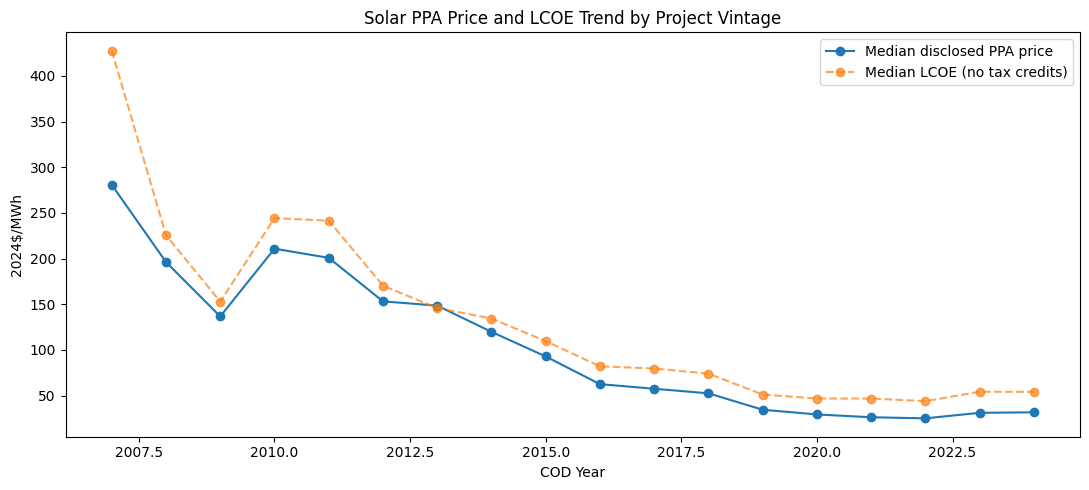

,Solar COD Year,median_ppa,median_lcoe,n
0,2007,280.703651,427.520,1
1,2008,196.154181,225.540,1
2,2009,136.590717,152.830,1
3,2010,210.779211,244.255,6
4,2011,200.780394,241.460,10
5,2012,153.116513,170.270,16
6,2013,148.438438,145.790,13
7,2014,119.742411,134.350,25
8,2015,92.785409,109.520,28
9,2016,62.474303,82.000,62


In [5]:
LCOE_COL = "PV LCOE no Tax Credits (2024$/MWh)"

by_year = projects.groupby("Solar COD Year").agg(
    median_ppa=(PPA_COL, "median"),
    median_lcoe=(LCOE_COL, "median"),
    n=(PPA_COL, "count"),
).reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(by_year["Solar COD Year"], by_year["median_ppa"], marker="o", label="Median disclosed PPA price")
ax.plot(by_year["Solar COD Year"], by_year["median_lcoe"], marker="o", linestyle="--",
        label="Median LCOE (no tax credits)", alpha=0.7)
ax.set_xlabel("COD Year")
ax.set_ylabel("2024$/MWh")
ax.set_title("Solar PPA Price and LCOE Trend by Project Vintage")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/ppa_price_trend.png", dpi=150)
plt.show()

by_year


PPA price tracks LCOE closely across the full period, and both fall roughly 85% from
2010-2011 vintage to 2022-2024 vintage — this independently reproduces LBNL's own published
industry trend, a useful sanity check that this dataset behaves as expected before trusting
anything more specific built on top of it.

## 5. The valid benchmark comparison (matching vintage only)

Restrict to 2022-2024 vintage projects — the same era as the benchmark itself — before
comparing against it. This is the fixed version of section 3.

In [6]:
df = build_pricing_table()
df.to_csv(f"{PROCESSED_DIR}/pricing_table.csv", index=False)
print(f"Saved {len(df)} rows to data/processed/pricing_table.csv")


Loaded 1775 total projects.
  -> 1759 after restricting to Solar Tech Main == 'PV' (excludes CSP)
  -> 425 after keeping only rows with a disclosed PPA price (24% of PV projects have one)

These will have a NaN benchmark comparison rather than being silently dropped.
Saved 425 rows to data/processed/pricing_table.csv


In [7]:
MIN_SEGMENT_N = 5
recent = df[df["Solar COD Year"] >= 2022].copy()
print(f"{len(recent)} projects from 2022-2024 vintage with a disclosed PPA price.")

rows = []
for segment_col in ["Region", "Offtaker Type"]:
    for value, group in recent.groupby(segment_col):
        n = len(group)
        n_with_benchmark = group["vs_levelten_usd_mwh"].notna().sum()
        if n < MIN_SEGMENT_N:
            status, mean_val = "too few projects", None
        elif n_with_benchmark < MIN_SEGMENT_N:
            status, mean_val = "benchmark unavailable for this region", None
        else:
            status, mean_val = "reliable", group["vs_levelten_usd_mwh"].mean()
        rows.append({"segment_type": segment_col, "segment_value": value, "n": n,
                     "n_with_benchmark": n_with_benchmark, "mean_vs_levelten": mean_val,
                     "status": status})

segments = pd.DataFrame(rows)
segments.to_csv(f"{PROCESSED_DIR}/recent_vintage_segments.csv", index=False)
segments


107 projects from 2022-2024 vintage with a disclosed PPA price.


,segment_type,segment_value,n,n_with_benchmark,mean_vs_levelten,status
0,Region,CAISO,21,21,-18.188656,reliable
1,Region,ISO-NE,1,1,NaN,too few projects
2,Region,MISO,13,13,-13.797086,reliable
3,Region,NYISO,12,0,NaN,benchmark unavailable for this region
4,Region,PJM,15,15,-28.589472,reliable
5,Region,SPP,2,2,NaN,too few projects
6,Region,Southeast (non-ISO),9,0,NaN,benchmark unavailable for this region
7,Region,West (non-ISO),34,0,NaN,benchmark unavailable for this region
8,Offtaker Type,Corporate,15,8,-33.350460,reliable
9,Offtaker Type,Investor-owned Utility,31,11,-11.004384,reliable


## 6. The diagnosis — why every reliable segment shows a negative gap

Every segment with enough data to trust (n >= 5, and a real benchmark value available) shows
realized prices **$11-33/MWh below** the LevelTen/Trio index — not scattered around zero. That
consistency is itself the signal that something structural was going on, not deal-specific
pricing skill.

Checked directly against LevelTen Energy's own published methodology:

> "The offers underlying our Index are from projects that are currently under development and
> posted by developers to the LevelTen Marketplace... giving the industry a transparent and
> unprecedented look at actual PPA price offers — **not estimates of what PPA prices could or
> should be.**"

Two structural facts this confirms:
- The index is built from **developer-submitted offer prices** for projects still seeking a
  buyer — not realized, signed prices for completed projects like LBNL's data.
- LevelTen's own published figure is specifically the **P25** (25th percentile) of those
  offers — the more aggressive end of the distribution, not a central "typical" price.

**Conclusion:** a realized/signed price coming in below a P25 asking-price index is close to
the expected outcome of comparing two different stages of the deal-making process, not evidence
that any particular segment negotiated better. This reframes the whole project's core
deliverable — see the README's Recommendation section for what this actually implies for a
pricing-analyst context.

## 7. Summary

- Full-history trend: real, independently-reproduced ~85% PPA price decline by vintage,
  tracking LCOE closely.
- Naive benchmark comparison across all vintages: caught and fixed a genuine methodology
  mistake (vintage mismatch) before it became a wrong headline finding.
- Vintage-matched benchmark comparison: consistent negative gap across every reliable segment.
- Diagnosis: that consistency is best explained by a benchmark-methodology mismatch (offer
  price vs. realized price), confirmed against the benchmark provider's own documentation —
  not by any segment negotiating better deals.

Outputs saved: `data/processed/pricing_table.csv`, `data/processed/recent_vintage_segments.csv`,
`data/processed/ppa_price_trend.png`.
